###Import Statements

In [ ]:
import itertools
import random
import time
import ast
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
import gc

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Reading data

In [ ]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/medium_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

hwb5_54 5 24
hwb6_57 6 65
ham7_104 7 23
cycle17_3_112 20 48
mod5adder_127 6 21
rd53_131 7 28
rd84_142 15 28
0410184_169 14 46
mux_246 22 35
ryy6_256 17 44
squar5_261 13 43
cycle10_293 39 78
hwb5_300 28 88
sym6_316 14 29


In [ ]:
np_any = np.any
np_array = np.array

##Helper Functions for algorithm
###1. Fault simulators
####a.simulate circuit
####b.simulate faulty saf
####c.simulate faulty mmgf
####d.simulate faulty smgf
####e.simulate faulty pmgf
####f.simulate faulty caf
####g.simulate faulty gaf
####h.simulate faulty bf

###2. generate fault list with types
###3. detection
###4. remove redundancy

In [ ]:
def simulate_circuit(circuit, input_vector):
    """Simulate a circuit on a given input vector (no faults)."""
    vec = np_array(input_vector, copy=True)
    for gate in circuit:
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec


    # =====================================================
#  FAULT SIMULATORS
# =====================================================

def simulate_faulty_saf(circuit, input_vector, fault):
    vec = input_vector.copy()
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            vec[fault["wire"]] = fault["value"]
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

def simulate_faulty_mmgf(circuit, input_vector, fault):
    faulty_circuit = [g for i,g in enumerate(circuit) if i != fault["location"]]
    return simulate_circuit(faulty_circuit, input_vector.copy())

def simulate_faulty_smgf(circuit, input_vector, fault):
    return simulate_faulty_mmgf(circuit, input_vector, fault)

def simulate_faulty_pmgf(circuit, input_vector, fault):
    vec = input_vector.copy()
    for i, gate in enumerate(circuit):
        gtype = gate[0].upper()
        if i == fault["location"]:
            if gtype == "TOFFOLI":
                _, target = gate[1], gate[2]
                vec[target] ^= 1  # unconditional flip
            elif gtype == "FREDKIN":
                _, s1, s2 = gate[1]
                vec[s1], vec[s2] = vec[s2], vec[s1]
        else:
            if gtype == "TOFFOLI":
                controls, target = gate[1], gate[2]
                if all(vec[c] == 1 for c in controls):
                    vec[target] ^= 1
            elif gtype == "FREDKIN":
                controls, s1, s2 = gate[1]
                if all(vec[c] == 1 for c in controls):
                    vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

def simulate_faulty_gaf(circuit, input_vector, fault):
    """
    GAF: Add an extra gate at a given location.
    fault['extra_gate'] should be a valid gate tuple.
    """
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            faulty_circuit.append(fault["extra_gate"])  # insert before the real gate
        faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)


def simulate_faulty_caf(circuit, input_vector, fault):
    """
    CAF: Control Appearance Fault.
    Add an extra control line to the gate at fault['location'].
    """
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        gtype = gate[0].upper()
        if i == fault["location"]:
            if gtype == "TOFFOLI":
                controls, target = gate[1], gate[2]
                # add the extra control if not already present
                new_controls = list(controls)
                if fault["control"] not in new_controls:
                    new_controls.append(fault["control"])
                faulty_circuit.append(("TOFFOLI", new_controls, target))
            elif gtype == "FREDKIN":
                controls, s1, s2 = gate[1]
                new_controls = list(controls)
                if fault["control"] not in new_controls:
                    new_controls.append(fault["control"])
                faulty_circuit.append(("FREDKIN", (new_controls, s1, s2)))
            else:
                faulty_circuit.append(gate)
        else:
            faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)


def simulate_faulty_bf(circuit, input_vector, fault):
    """
    BF: Bridging Fault – wires shorted together (AND or OR).
    """
    vec = input_vector.copy()
    for gate in circuit:
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]

        # Apply bridging after each gate
        if fault["mode"] == "AND":
            val = vec[fault["wire1"]] & vec[fault["wire2"]]
        else:  # OR
            val = vec[fault["wire1"]] | vec[fault["wire2"]]
        vec[fault["wire1"]] = vec[fault["wire2"]] = val
    return vec

def generate_fault_list_with_types(circuit, n_inputs, include=("SAF","SMGF","MMGF","PMGF")):
    fault_list = []

    if "SAF" in include:
        for gate_idx in range(len(circuit)):
            for wire in range(n_inputs):
                for val in [0, 1]:
                    fault_list.append({
                        "id": f"SAF_{gate_idx}_{wire}_{val}",
                        "type": "SAF",
                        "location": gate_idx,
                        "wire": wire,
                        "value": val
                    })
    if "SMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"SMGF_{i}", "type": "SMGF", "location": i})
    if "MMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"MMGF_{i}", "type": "MMGF", "location": i})
    if "PMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"PMGF_{i}", "type": "PMGF", "location": i})

    if "GAF" in include:
        for i in range(len(circuit)):
            fault_list.append({
                "id": f"GAF_{i}",
                "type": "GAF",
                "location": i,
                "extra_gate": ("TOFFOLI", [], 0)  # unconditional NOT on wire 0
            })

    if "CAF" in include:
        for i in range(len(circuit)):
            for w in range(n_inputs):
                fault_list.append({
                    "id": f"CAF_{i}_{w}",
                    "type": "CAF",
                    "location": i,
                    "control": w
                })

    if "BF" in include:
        for w1 in range(n_inputs):
            for w2 in range(w1+1, n_inputs):
                for mode in ["AND","OR"]:
                    fault_list.append({
                        "id": f"BF_{w1}_{w2}_{mode}",
                        "type": "BF",
                        "wire1": w1,
                        "wire2": w2,
                        "mode": mode
                    })
    return fault_list

from functools import lru_cache

# Use lru_cache with a maxsize to limit memory usage
@lru_cache(maxsize=10000) # Adjust maxsize as needed
def detect_fault(vector_tuple, fault_id, circuit_tuple, normal_cache_tuple):
    """Detect if a given input vector detects a specific fault."""
    # Convert tuples back to mutable types if necessary for simulation
    vector = list(vector_tuple)
    circuit = list(circuit_tuple)

    pass # This function will be updated in the next cell modification

def detect_fault(dp, vector, fault, circuit, normal_cache):
    vkey = tuple(vector)
    if vkey not in normal_cache:
        normal_cache[vkey] = simulate_circuit(circuit, vector)
    normal_output = normal_cache[vkey]

    # Create a hashable key for the fault
    fault_key = (fault["type"], fault.get("location"), fault.get("wire"), fault.get("value"),
                 fault.get("wire1"), fault.get("wire2"), fault.get("mode"),
                 # Need a hashable representation of extra_gate or control if they exist
                 # For simplicity, let's assume these specific fault types have simple hashable parameters
                 fault.get("control")) # Added control for CAF

    key = (vkey, fault_key) # Use the hashable fault_key

    if key in dp:
        return dp[key]

    # Simulate the faulty circuit based on fault type
    if fault["type"] == "SAF":
        faulty_output = simulate_faulty_saf(circuit, vector, fault)
    elif fault["type"] == "SMGF":
        faulty_output = simulate_faulty_smgf(circuit, vector, fault)
    elif fault["type"] == "MMGF":
        faulty_output = simulate_faulty_mmgf(circuit, vector, fault)
    elif fault["type"] == "PMGF":
        faulty_output = simulate_faulty_pmgf(circuit, vector, fault)
    elif fault["type"] == "GAF":

        gaf_fault_key = (fault["type"], fault.get("location"), tuple(fault.get("extra_gate", ("None",)))) # Added extra_gate for GAF
        key = (vkey, gaf_fault_key) # Update key for GAF

        if key in dp: # Check DP again with the specific GAF key
            return dp[key]

        faulty_output = simulate_faulty_gaf(circuit, vector, fault)
    elif fault["type"] == "CAF":
         # CAF fault key already includes control
         faulty_output = simulate_faulty_caf(circuit, vector, fault)
    elif fault["type"] == "BF":
         # BF fault key already includes wire1, wire2, mode
         faulty_output = simulate_faulty_bf(circuit, vector, fault)
    else:
        raise ValueError(f"Unknown fault type: {fault['type']}")

    # Fix: Use np.any() to compare the output arrays element-wise
    detected = np.any(normal_output != faulty_output)
    dp[key] = detected
    return detected


def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    # Use BoundedDicts for the compaction process as well
    # These caches are local to this function call
    dp = BoundedDict(maxsize=100000) # Use the same cache size as in run_ga or adjust
    normal_cache = BoundedDict(maxsize=10000) # Use the same cache size as in run_ga or adjust

    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            # detect_fault uses the local bounded caches
            if fault["id"] not in covered and detect_fault(dp, vec, fault, circuit, normal_cache):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced

##Genetic Algorithm functions
###1. Fitness dp hybrid
###2. Mutate
###3. Crossover


In [ ]:
def compute_fitness_dp_hybrid(individual, fault_list, circuit, dp, normal_cache, gen=None, max_gen=None):
    uncovered_faults = set(f["id"] for f in fault_list)
    detected_faults = set()
    fault_map = {f["id"]: f for f in fault_list}

    for vector in individual:
        newly_detected = set()
        for fault_id in list(uncovered_faults):
            if detect_fault(dp, vector, fault_map[fault_id], circuit, normal_cache):
                newly_detected.add(fault_id)
        detected_faults.update(newly_detected)
        uncovered_faults -= newly_detected

    coverage = len(detected_faults) / len(fault_list) if fault_list else 0.0

    if gen is not None and max_gen:
        alpha = 100 + (200 * (gen / max_gen))
        beta = 0.1 * (gen / max_gen)
    else:
        alpha, beta = 200, 0.05

    fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, len(fault_list), detected_faults

    # ---------- GA Operators ---------- #
def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def adaptive_mutate(individual, gen, max_gen, base_rate=0.3):
    rate = base_rate * (1 - gen / max_gen) + 0.05  # gradually reduce mutation
    for vec in individual:
        if random.random() < rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

def breed_population(sorted_pop, pop_size, elitism, gen, max_gen):
    next_gen = sorted_pop[:elitism]
    top_half = sorted_pop[:pop_size // 2]

    while len(next_gen) < pop_size:
        p1, p2 = random.sample(top_half, 2)
        child = crossover(p1, p2)
        child = adaptive_mutate(child, gen, max_gen)
        next_gen.append(child)

    # inject diversity every 10 gens
    if gen % 10 == 0:
        for _ in range(min(3, pop_size // 10)):
            rand_vec = [np.random.randint(0, 2, len(top_half[0][0])) for _ in range(random.randint(2, 5))]
            next_gen.append(rand_vec)

    return next_gen[:pop_size]



In [ ]:
# The original run_ga is almost fine. We just swap the fitness function.

# Define a simple bounded dictionary
class BoundedDict(OrderedDict):
    def __init__(self, *args, maxsize=1000, **kwargs):
        self.maxsize = maxsize
        super().__init__(*args, **kwargs)

    def __setitem__(self, key, value):
        super().__setitem__(key, value)
        if len(self) > self.maxsize:
            oldest = next(iter(self))
            del self[oldest]

##Genetic Algorithm Loop
###1. generate fault list
###2. generate population random
###3. compute fitness for each individual
###4. sort the population and carry forward top half in next gen
###5. perform crossover
###6. mutation
###7. add the child to the populn
###8. get the best individual from the population
###9. remove redundancy from the best individual
###10. log the results and return the best results
###11. Early stopping

In [ ]:



def run_ga(
    circuit, n_inputs,
    fault_models=("MMGF",),
    generations=80, pop_size=60, max_vecs=25, runs=3,
    mutation_rate=0.3, elitism=3,
    dp_cache_size=120000, normal_cache_size=15000
):
    fault_list = generate_fault_list_with_types(circuit, n_inputs, include=fault_models)
    best_results = []

    normal_cache = BoundedDict(maxsize=normal_cache_size)
    dp = BoundedDict(maxsize=dp_cache_size)

    STAGNATION_LIMIT = 15
    MAX_RUNTIME = 240  # seconds
    COVERAGE_THRESHOLD = 0.999

    for run_idx in range(runs):
        population = [
            [np.random.randint(0, 2, n_inputs) for _ in range(random.randint(2, max_vecs))]
            for _ in range(pop_size)
        ]

        best = None
        best_score = -1e9
        best_cov = 0.0
        stagnation_counter = 0
        last_best_coverage = 0.0
        start = time.time()

        print(f"\n--- Starting Optimized Run {run_idx+1}/{runs} ---")

        for gen in range(generations):
            if time.time() - start > MAX_RUNTIME:
                print(f"⏰ Run {run_idx+1} stopped (timeout {MAX_RUNTIME}s)")
                break

            fitness_data = []
            for ind in population:
                fitness, coverage, total_faults, detected = compute_fitness_dp_hybrid(ind, fault_list, circuit, dp, normal_cache, gen, generations)
                fitness_data.append((fitness, ind, coverage, detected))
                if fitness > best_score:
                    best, best_score, best_cov, best_detected = ind, fitness, coverage, detected

            fitness_data.sort(key=lambda x: x[0], reverse=True)
            sorted_pop = [ind for (_, ind, _, _) in fitness_data]
            population = breed_population(sorted_pop, pop_size, elitism, gen, generations)

            # --- Early Stopping ---
            if best_cov > last_best_coverage:
                stagnation_counter = 0
                last_best_coverage = best_cov
            else:
                stagnation_counter += 1

            if stagnation_counter >= STAGNATION_LIMIT:
                print(f"⚠️ Early stop (no improvement for {STAGNATION_LIMIT} gens)")
                break
            if best_cov >= COVERAGE_THRESHOLD:
                print(f"✅ Coverage saturation ({best_cov*100:.2f}%)")
                break

            if gen % 10 == 0:
                print(f"Gen {gen}: Cov={best_cov*100:.2f}%, Len={len(best)}, Time={time.time()-start:.1f}s")

        print(f"\nFinal Compaction for Run {run_idx+1}: Pre-Length={len(best)}")
        best_comp = remove_redundant_vectors(best, circuit, fault_list)
        final_fitness, final_cov, total_faults, detected_faults = compute_fitness_dp_hybrid(best_comp, fault_list, circuit, dp, normal_cache)
        print(f"Final Compaction: Post-Length={len(best_comp)}, Cov={final_cov*100:.2f}%")

        best_results.append((best_comp, (final_fitness, final_cov, len(fault_list), detected_faults)))

    return best_results


###Run over the benchmark circuits

In [ ]:
def convert_dataset_gates(dataset_gates, variables):
    if isinstance(variables,str):
        variables = ast.literal_eval(variables)
    var_map = {v:i for i,v in enumerate(variables)}
    circuit = []
    for g in dataset_gates:
        if not isinstance(g,dict) or "gate" not in g or "vars" not in g:
            continue
        gate_name = str(g["gate"]).lower()
        idxs = [var_map[n] for n in g["vars"] if n in var_map]
        if len(idxs)==0: continue
        if gate_name.startswith("t"):
            controls, target = ([],idxs[0]) if len(idxs)==1 else (idxs[:-1], idxs[-1])
            circuit.append(("TOFFOLI",controls,target))
        elif gate_name.startswith("f"):
            if len(idxs)<2: continue
            controls, s1, s2 = idxs[:-2], idxs[-2], idxs[-1]
            circuit.append(("FREDKIN",(controls,s1,s2)))
    return circuit


In [ ]:
def run_on_dataset(df, save_csv_path="ga_results.csv", fault_models=("SAF",)):
    results = []
    if isinstance(fault_models, str):
        fault_models = (fault_models,)
    for _, row in df.iterrows():
        circuit = convert_dataset_gates(row["gates"], row["variables"])
        n_inputs = int(row["numvars"])

        if not circuit:
            print(f"⚠️ {row['circuit_name']} → Empty/unsupported circuit.")
            continue

        start = time.time()
        best_runs = run_ga(circuit, n_inputs, fault_models=fault_models)
        end = time.time()

        best_test_set, (fitness, coverage, total_faults, detected_faults) = max(best_runs, key=lambda x: x[1][0])
        results.append({
            "file": row['circuit_name'],
            "fitness": round(fitness,4),
            "coverage": round(coverage,4),
            "total_faults": total_faults,
            "detected_faults": len(detected_faults),
            "num_test_vectors": len(best_test_set),
            "num_gates": len(circuit),
            "exec_time_sec": round(end-start,2)
        })

    with open(save_csv_path,"w",newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["file","fitness","coverage","total_faults","detected_faults","num_test_vectors","num_gates","exec_time_sec"])
        writer.writeheader()
        for r in results: writer.writerow(r)
    return results

###Visualiza the Results

In [ ]:
def plot_gates_coverage_vectors(results):
    files = [r["file"] for r in results]
    num_gates = [r["num_gates"] for r in results]
    coverage = [r["coverage"] for r in results]
    num_vectors = [r["num_test_vectors"] for r in results]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))
    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()
    plt.show()


def plot_coverage_vs_vectors(results):
    x = [r["num_test_vectors"] for r in results]
    y = [r["coverage"] for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    efficiency = [(r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0 for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

In [ ]:
# Run GA + DP on the dataset
results = run_on_dataset(df_circuits, save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/Results/opti_medium_saf.csv", fault_models=('SAF'))


--- Starting Optimized Run 1/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 1: Pre-Length=22
Final Compaction: Post-Length=7, Cov=100.00%

--- Starting Optimized Run 2/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 2: Pre-Length=20
Final Compaction: Post-Length=4, Cov=100.00%

--- Starting Optimized Run 3/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 3: Pre-Length=21
Final Compaction: Post-Length=6, Cov=100.00%

--- Starting Optimized Run 1/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 1: Pre-Length=7
Final Compaction: Post-Length=5, Cov=100.00%

--- Starting Optimized Run 2/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 2: Pre-Length=10
Final Compaction: Post-Length=7, Cov=100.00%

--- Starting Optimized Run 3/3 ---
✅ Coverage saturation (100.00%)

Final Compaction for Run 3: Pre-Length=17
Final Compaction: Post-Length=8, Cov=100.00%

--- Starting Optimized Run 1/3 ---
✅ Coverage saturation (100.00

In [ ]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [ ]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



hwb5_54 → gates: 24, vectors: 4, time: 1.12 sec
hwb6_57 → gates: 65, vectors: 5, time: 5.8 sec
ham7_104 → gates: 23, vectors: 5, time: 1.88 sec
cycle17_3_112 → gates: 48, vectors: 5, time: 60.54 sec
mod5adder_127 → gates: 21, vectors: 3, time: 1.58 sec
rd53_131 → gates: 28, vectors: 5, time: 2.43 sec
rd84_142 → gates: 28, vectors: 5, time: 16.13 sec
0410184_169 → gates: 46, vectors: 6, time: 33.51 sec
mux_246 → gates: 35, vectors: 5, time: 37.96 sec
ryy6_256 → gates: 44, vectors: 6, time: 41.62 sec
squar5_261 → gates: 43, vectors: 5, time: 28.31 sec
cycle10_293 → gates: 78, vectors: 6, time: 259.88 sec
hwb5_300 → gates: 88, vectors: 8, time: 233.5 sec
sym6_316 → gates: 29, vectors: 5, time: 15.41 sec


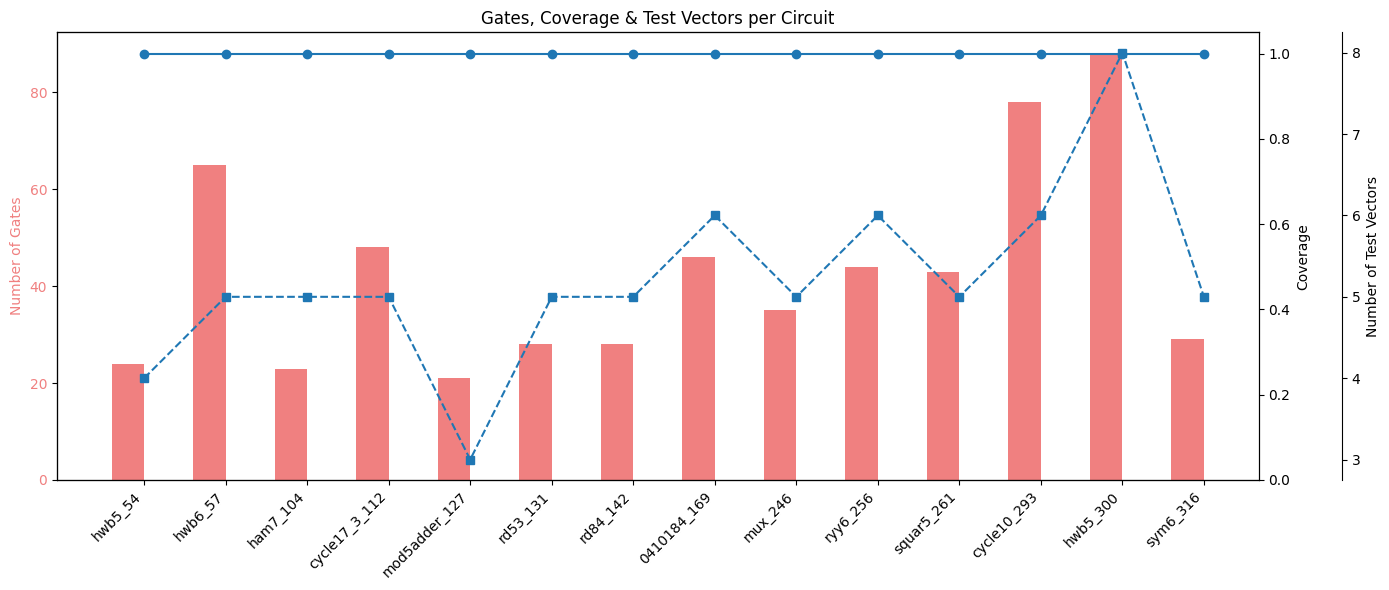

In [ ]:
plot_gates_coverage_vectors(results)


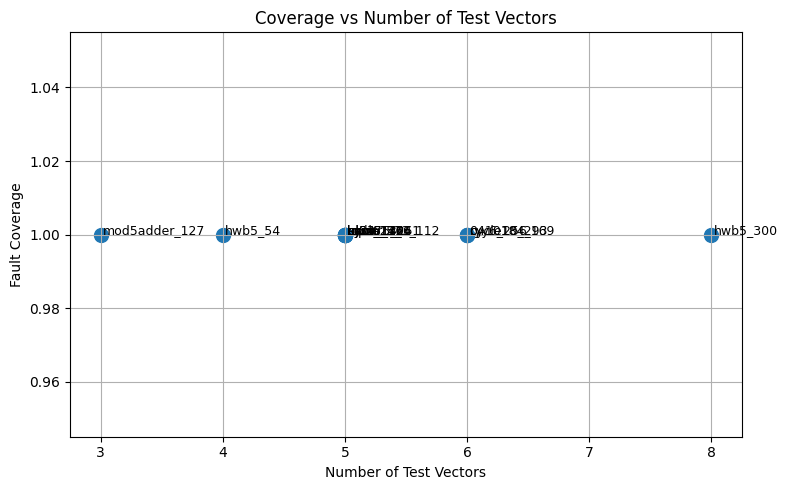

In [ ]:
plot_coverage_vs_vectors(results)

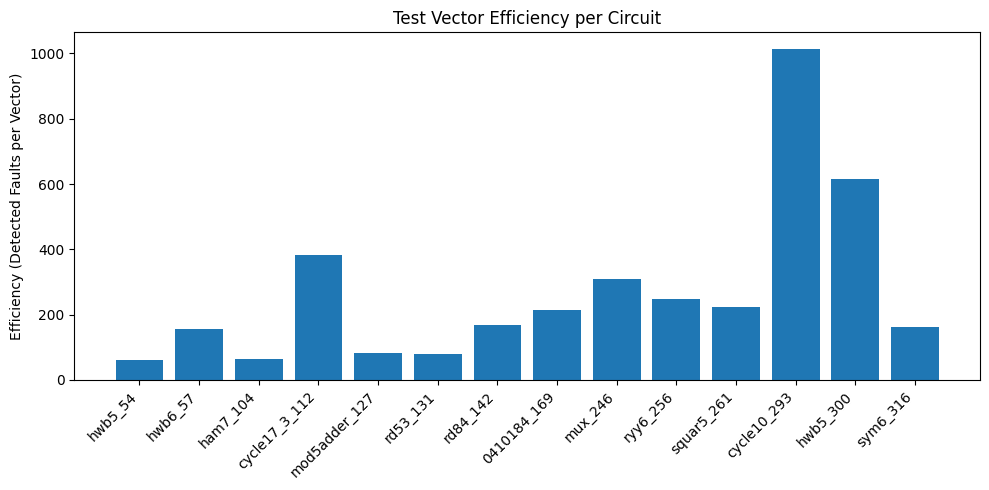

In [ ]:
plot_efficiency(results)
# ---------- Example Execution ---------- #


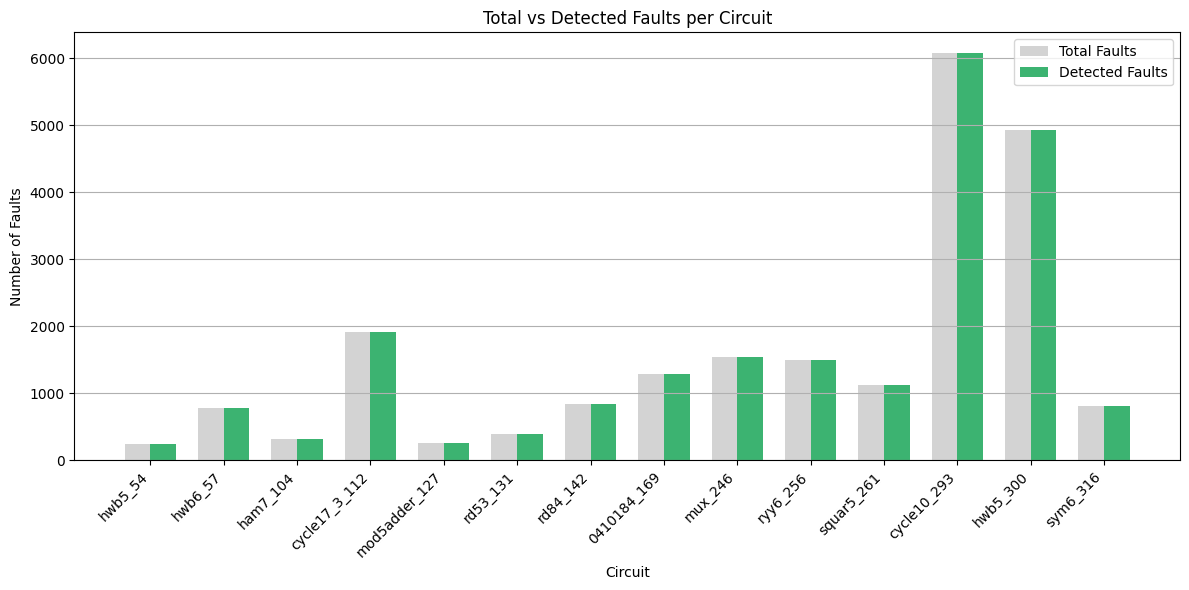

In [ ]:
plot_faults_per_circuit(results)
